In [1]:
!conda install -c conda-forge awswrangler -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/ec2-user/anaconda3/envs/python3

  added / updated specs:
    - awswrangler


The following packages will be DOWNGRADED:

  numpy                               2.4.3-py312h33ff503_0 --> 2.2.6-py312h72c5963_0 




Preparing transaction: done
Verifying transaction: done
Executing transaction: done


In [2]:
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns
import awswrangler as wr

In [ ]:
from cluster_naming import name_alignment_clusters

In [4]:
import awswrangler as wr

def query_athena(query, database='nfl_data'):
    """Execute Athena query and return DataFrame"""
    df = wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False
    )
    return df

In [5]:
query_align = """
SELECT  
    player_id,
    player,
    team,
    position_group,
    season,
    pass_plays,
    wide_snaps,
    slot_snaps,
    inline_snaps,
    behind_snaps
FROM nfl_data.vw_receiving_clustering_base
WHERE wide_snaps IS NOT NULL
AND slot_snaps IS NOT NULL
AND inline_snaps IS NOT NULL
AND behind_snaps IS NOT NULL
AND pass_plays IS NOT NULL
"""

print("Querying Athena...")
df_align = query_athena(query_align)
print(f"Loaded {len(df_align):,} player-seasons")

Querying Athena...
Loaded 6,255 player-seasons


In [6]:
df_align

,player_id,player,team,position_group,season,pass_plays,wide_snaps,slot_snaps,inline_snaps,behind_snaps
0,97399.0,Jamari Thrash,CLV,WR,2024.0,98.0,35.0,63.0,0.0,0.0
1,131705.0,Trey Benson,ARZ,HB,2024.0,63.0,10.0,0.0,0.0,53.0
2,129604.0,Roman Wilson,PIT,WR,2024.0,1.0,1.0,0.0,0.0,0.0
3,172430.0,Isaac TeSlaa,DET,WR,2025.0,312.0,220.0,90.0,1.0,1.0
4,9964.0,Damiere Byrd,NE,WR,2020.0,496.0,451.0,45.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
6250,84480.0,Deven Thompkins,TB,WR,2022.0,46.0,38.0,7.0,0.0,1.0
6251,154173.0,Emanuel Wilson,GB,HB,2024.0,143.0,14.0,7.0,1.0,121.0
6252,8691.0,Cody Latimer,DEN,WR,2017.0,246.0,108.0,137.0,1.0,0.0
6253,45859.0,Travis Homer,CHI,HB,2024.0,65.0,5.0,2.0,0.0,58.0


In [7]:
df_align['wide_rate'] = (df_align['wide_snaps'] / df_align['pass_plays'] * 100).round(1)
df_align['slot_rate'] = (df_align['slot_snaps'] / df_align['pass_plays'] * 100).round(1)
df_align['inline_rate'] = (df_align['inline_snaps'] / df_align['pass_plays'] * 100).round(1)
df_align['behind_rate'] = (df_align['behind_snaps'] / df_align['pass_plays'] * 100).round(1)

# Define features for clustering
features = ['wide_rate', 'slot_rate', 'inline_rate', 'behind_rate']

print("\nAlignment Rate Summary:")
print(df_align[features].describe())

# Create filtered dataset (pass_plays >= 35) for training
df_align_filtered = df_align[df_align['pass_plays'] >= 35].copy()
print(f"\nFiltered to {len(df_align_filtered):,} player-seasons with >= 35 pass plays")


Alignment Rate Summary:
         wide_rate    slot_rate  inline_rate  behind_rate
count  6255.000000  6255.000000  6255.000000  6255.000000
mean     28.789097    22.996403    15.658289    32.555076
std      31.136277    23.666299    28.406554    42.274577
min       0.000000     0.000000     0.000000     0.000000
25%       3.450000     2.500000     0.000000     0.000000
50%      13.200000    16.600000     0.000000     1.400000
75%      58.100000    35.700000    17.550000    84.500000
max     100.000000   100.000000   100.000000   100.000000

Filtered to 4,424 player-seasons with >= 35 pass plays


In [8]:
# Prepare clustering data from FILTERED dataset
X_align_values = df_align_filtered[features].values

# Create sample weights based on pass_plays (for filtered data)
weights_align = np.sqrt(df_align_filtered['pass_plays'].values)

print(f"\nClustering on {len(X_align_values):,} filtered player-seasons")
print(f"Weight range: {weights_align.min():.1f} to {weights_align.max():.1f}")


Clustering on 4,424 filtered player-seasons
Weight range: 5.9 to 28.7


Running elbow method analysis...
k=2: Inertia=101,329,969, Silhouette=0.600
k=3: Inertia=46,181,077, Silhouette=0.655
k=4: Inertia=19,958,184, Silhouette=0.681
k=5: Inertia=14,958,558, Silhouette=0.658
k=6: Inertia=11,181,435, Silhouette=0.624
k=7: Inertia=9,484,217, Silhouette=0.614
k=8: Inertia=7,888,667, Silhouette=0.515
k=9: Inertia=6,623,951, Silhouette=0.498
k=10: Inertia=6,006,519, Silhouette=0.486


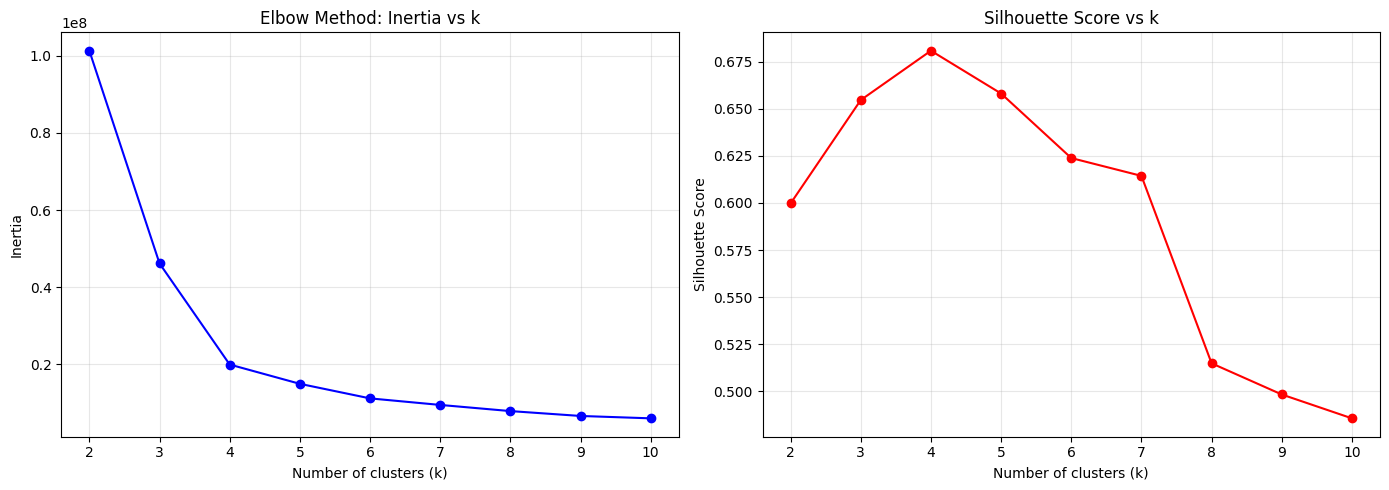


Optimal k appears to be around 6 (elbow in inertia + good silhouette score)


In [9]:
# ----------------------------------------------------------------------
# ## Elbow Method - Finding Optimal k
# ----------------------------------------------------------------------

print("Running elbow method analysis...")

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=25, random_state=42)
    kmeans.fit(X_align_values, sample_weight=weights_align)
    inertias.append(kmeans.inertia_)
    
    # Silhouette score (no sample_weight support in sklearn)
    labels = kmeans.labels_
    score = silhouette_score(X_align_values, labels)
    silhouette_scores.append(score)
    
    print(f"k={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={score:.3f}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Inertia plot
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method: Inertia vs k')
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nOptimal k appears to be around 6 (elbow in inertia + good silhouette score)")


In [ ]:
# ----------------------------------------------------------------------
# ## Cluster Naming (AUTO)
# ----------------------------------------------------------------------

# Auto-name based on centroid rules
cluster_names = name_alignment_clusters(centroids)

print("Auto-assigned names:")
for cluster, name in sorted(cluster_names.items()):
    print(f"  Cluster {cluster} → {name}")


FINAL CLUSTERING: k=6

Cluster Centroids (k=6):
   cluster  count  wide_rate  slot_rate  inline_rate  behind_rate
0        2    559        8.2       17.7         70.4          3.7
1        4    478       14.5       43.0         39.4          3.0
2        3    468       25.5       71.7          1.9          0.8
3        1   1420        6.6        5.3          1.4         86.7
4        5    617       57.9       40.8          0.7          0.7
5        0    882       79.7       19.9          0.3          0.2


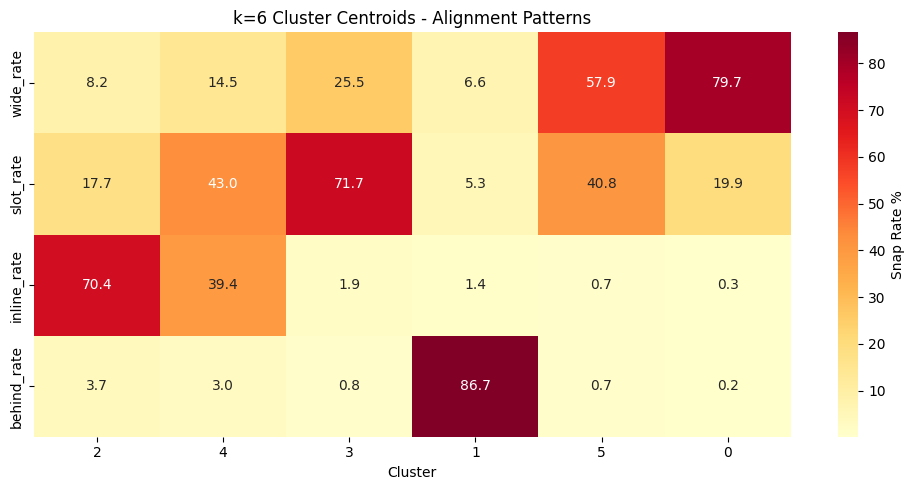


LOOK AT THE CENTROIDS ABOVE
Decide which cluster is:
- ITE (high inline_rate)
- STE (moderate inline + slot)
- WWR (high wide_rate)
- SWR (high slot_rate)
- WSWR (mix wide/slot)
- RB (high behind_rate)


In [11]:
# ----------------------------------------------------------------------
# ## Final Clustering with k=6
# ----------------------------------------------------------------------

print("\n" + "="*60)
print("FINAL CLUSTERING: k=6")
print("="*60)

# Run final clustering on FILTERED data
kmeans_final = KMeans(n_clusters=6, n_init=25, random_state=42)
kmeans_final.fit(X_align_values, sample_weight=weights_align)

# Get cluster assignments for filtered players
labels_final = kmeans_final.labels_
df_align_filtered['cluster'] = labels_final

# ============================================================================
# ANALYZE CENTROIDS - LOOK AT THESE TO DECIDE NAMES
# ============================================================================

# Create centroid dataframe
centroids = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=features
)
centroids['cluster'] = range(6)
centroids['count'] = pd.Series(labels_final).value_counts().sort_index().values

# Sort by inline_rate for easier interpretation
centroids = centroids.sort_values('inline_rate', ascending=False).reset_index(drop=True)

print("\nCluster Centroids (k=6):")
print(centroids[['cluster', 'count'] + features].round(1))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    centroids[features].T,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Snap Rate %'},
    xticklabels=centroids['cluster'],
    yticklabels=features,
    ax=ax
)
ax.set_title('k=6 Cluster Centroids - Alignment Patterns')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("LOOK AT THE CENTROIDS ABOVE")
print("="*60)
print("Decide which cluster is:")
print("- ITE (high inline_rate)")
print("- STE (moderate inline + slot)")
print("- WWR (high wide_rate)")
print("- SWR (high slot_rate)")
print("- WSWR (mix wide/slot)")
print("- RB (high behind_rate)")

In [ ]:
# ----------------------------------------------------------------------
# ## Cluster Naming (AUTO)
# ----------------------------------------------------------------------

# Auto-name based on centroid rules
cluster_names = name_alignment_clusters(centroids)

print("Auto-assigned names:")
for cluster, name in sorted(cluster_names.items()):
    print(f"  Cluster {cluster} → {name}")

In [13]:
# ----------------------------------------------------------------------
# ## Apply Clusters to ALL Players
# ----------------------------------------------------------------------

# Predict clusters for ALL players (including those with pass_plays < 50)
X_all = df_align[features].values
df_align['cluster'] = kmeans_final.predict(X_all)

# Map cluster numbers to names
df_align['cluster_name'] = df_align['cluster'].map(cluster_names)

# Verify counts
print("\nCluster assignments for ALL players:")
print(df_align['cluster_name'].value_counts())

# ============================================================================
# CREATE FINAL OUTPUT
# ============================================================================

output_final = df_align[['player_id', 'player', 'team', 'season', 'cluster_name']].copy()

print("\nSample Output:")
print(output_final.head(20).to_string(index=False))


Cluster assignments for ALL players:
cluster_name
RB      2197
WWR     1151
ITE      922
WSWR     792
SWR      637
STE      556
Name: count, dtype: int64

Sample Output:
 player_id            player team  season cluster_name
   97399.0     Jamari Thrash  CLV  2024.0          SWR
  131705.0       Trey Benson  ARZ  2024.0           RB
  129604.0      Roman Wilson  PIT  2024.0          WWR
  172430.0      Isaac TeSlaa  DET  2025.0          WWR
    9964.0      Damiere Byrd   NE  2020.0          WWR
   10927.0     Peyton Barber   LV  2021.0           RB
    6195.0      Kyle Rudolph   TB  2022.0          ITE
    8645.0        Eric Ebron  IND  2018.0          STE
   10674.0  Sterling Shepard   TB  2024.0         WSWR
   29413.0   Jeff Wilson Jr.  MIA  2025.0           RB
   10927.0     Peyton Barber   TB  2016.0           RB
   11192.0    Paul McRoberts   LA  2016.0          WWR
   48236.0    Darnell Mooney  CHI  2023.0          SWR
    9452.0    Cameron Erving  CAR  2022.0          ITE
   5

In [14]:
# ----------------------------------------------------------------------
# ## Save Results to S3
# ----------------------------------------------------------------------
# Save player clusters to player_clusters/alignment subfolder
csv_buffer = StringIO()
output_final.to_csv(csv_buffer, index=False)
s3_client = boto3.client('s3')
s3_client.put_object(
    Bucket='nfl-pff-data-lucas',
    Key='clustering/player_clusters/alignment/alignment_clusters_2025.csv',
    Body=csv_buffer.getvalue()
)
print("\n✓ Saved to s3://nfl-pff-data-lucas/clustering/player_clusters/alignment/alignment_clusters_2025.csv")
# Save centroids to centroids/alignment subfolder
centroids['name'] = centroids['cluster'].map(cluster_names)
centroids_buffer = StringIO()
centroids[['cluster', 'name', 'count'] + features].to_csv(centroids_buffer, index=False)
s3_client.put_object(
    Bucket='nfl-pff-data-lucas',
    Key='clustering/centroids/alignment/alignment_centroids_2025.csv',
    Body=centroids_buffer.getvalue()
)
print("✓ Saved centroids to s3://nfl-pff-data-lucas/clustering/centroids/alignment/alignment_centroids_2025.csv")
print("\n" + "="*60)
print("COMPLETE!")
print("="*60)


✓ Saved to s3://nfl-pff-data-lucas/clustering/player_clusters/alignment/alignment_clusters_2025.csv
✓ Saved centroids to s3://nfl-pff-data-lucas/clustering/centroids/alignment/alignment_centroids_2025.csv

COMPLETE!
